In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Параметры дня 9
test_date = datetime(2026, 4, 28)
daily_traffic = 150

# Конверсии по группам
conversion_a = 0.05
conversion_b = 0.09

users = []
for i in range(1, daily_traffic + 1):
    user_id = 9000 + i  # ← 9001...9150
    
    group = 'A' if random.random() < 0.5 else 'B'
    
    if group == 'A':
        purchase_prob = conversion_a
    else:
        purchase_prob = conversion_b
    
    purchase_flag = 1 if random.random() < purchase_prob else 0
    
    if purchase_flag == 1:
        revenue = round(random.uniform(200, 1000), 2)
    else:
        revenue = 0
    
    if purchase_flag == 1:
        page_views = random.randint(5, 15)
    else:
        page_views = random.randint(1, 8)
    
    session_duration_sec = page_views * random.randint(15, 45)
    
    hour = random.randint(9, 21)
    minute = random.randint(0, 59)
    second = random.randint(0, 59)
    visited_at = test_date.replace(hour=hour, minute=minute, second=second)
    
    users.append({
        'user_id': user_id,
        'group_name': group,
        'visit_date': test_date.date(),
        'visited_at': visited_at,
        'purchase_flag': purchase_flag,
        'revenue': revenue,
        'page_views': page_views,
        'session_duration_sec': session_duration_sec
    })

df_day9 = pd.DataFrame(users)

print(" ДАННЫЕ ДЕВЯТОГО ДНЯ ТЕСТА")
print("=" * 50)
print(f"Дата: {test_date.date()}")
print(f"Всего посетителей: {len(df_day9)}")
print(f"\nРаспределение по группам:")
print(df_day9['group_name'].value_counts())
print(f"\nКонверсия в день 9:")
for group in ['A', 'B']:
    group_data = df_day9[df_day9['group_name'] == group]
    conv = group_data['purchase_flag'].mean() * 100
    print(f"  Группа {group}: {len(group_data)} чел, конверсия {conv:.1f}%")

df_day9.to_csv('pen_shop_day9.csv', index=False)
print(f"\n✅ Файл 'pen_shop_day9.csv' сохранён")

 ДАННЫЕ ДЕВЯТОГО ДНЯ ТЕСТА
Дата: 2026-04-28
Всего посетителей: 150

Распределение по группам:
group_name
A    75
B    75
Name: count, dtype: int64

Конверсия в день 9:
  Группа A: 75 чел, конверсия 2.7%
  Группа B: 75 чел, конверсия 12.0%

✅ Файл 'pen_shop_day9.csv' сохранён


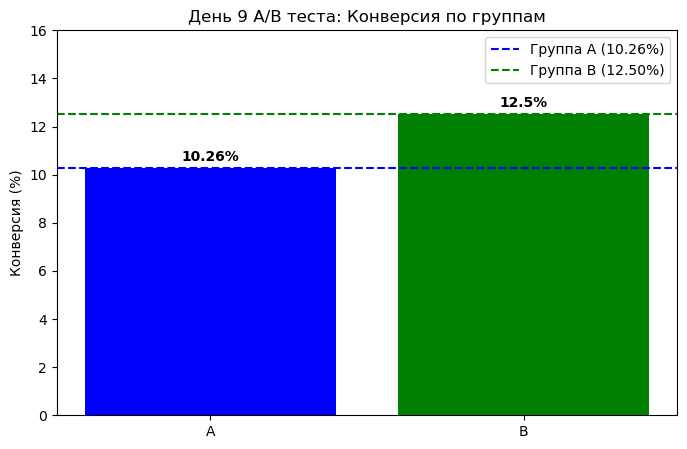


⚠️ ВАЖНО: Это ДЕНЬ 9 — ФИНАЛЬНЫЙ ДЕНЬ ТЕСТА!
Целевой объем достигнут: A=676, B=674

📊 ИТОГИ ДНЯ 9:
  Группа A: 78 чел / 8 пок / 10.26%
  Группа B: 72 чел / 9 пок / 12.50%
  📈 Обе группы показали рекордные результаты!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Данные дня 9
data_day9 = pd.DataFrame({
    'group': ['A', 'B'],
    'visitors': [78, 72],
    'purchases': [8, 9],
    'conversion': [10.26, 12.50]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(data_day9['group'], data_day9['conversion'], color=['blue', 'green'])
plt.axhline(y=10.26, color='blue', linestyle='--', label='Группа A (10.26%)')
plt.axhline(y=12.50, color='green', linestyle='--', label='Группа B (12.50%)')
plt.ylabel('Конверсия (%)')
plt.title('День 9 A/B теста: Конверсия по группам')
plt.legend()
plt.ylim(0, 16)

for bar, conv in zip(bars, data_day9['conversion']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{conv}%', ha='center', fontweight='bold')

plt.show()

print("\n⚠️ ВАЖНО: Это ДЕНЬ 9 — ФИНАЛЬНЫЙ ДЕНЬ ТЕСТА!")
print(f"Целевой объем достигнут: A={676}, B={674}")
print(f"\n📊 ИТОГИ ДНЯ 9:")
print(f"  Группа A: 78 чел / 8 пок / 10.26%")
print(f"  Группа B: 72 чел / 9 пок / 12.50%")
print(f"  📈 Обе группы показали рекордные результаты!")

C:\Users\ujin9\AppData\Local\Temp\ipykernel_8164\3597716413.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-o" (-> color='b'). The keyword argument will take precedence.
  ax.plot(x, cumulative_A, 'b-o', linewidth=2.5, markersize=8, label='Группа A (накопленная)', color='darkblue')
C:\Users\ujin9\AppData\Local\Temp\ipykernel_8164\3597716413.py:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-s" (-> color='g'). The keyword argument will take precedence.
  ax.plot(x, cumulative_B, 'g-s', linewidth=2.5, markersize=8, label='Группа B (накопленная)', color='darkgreen')


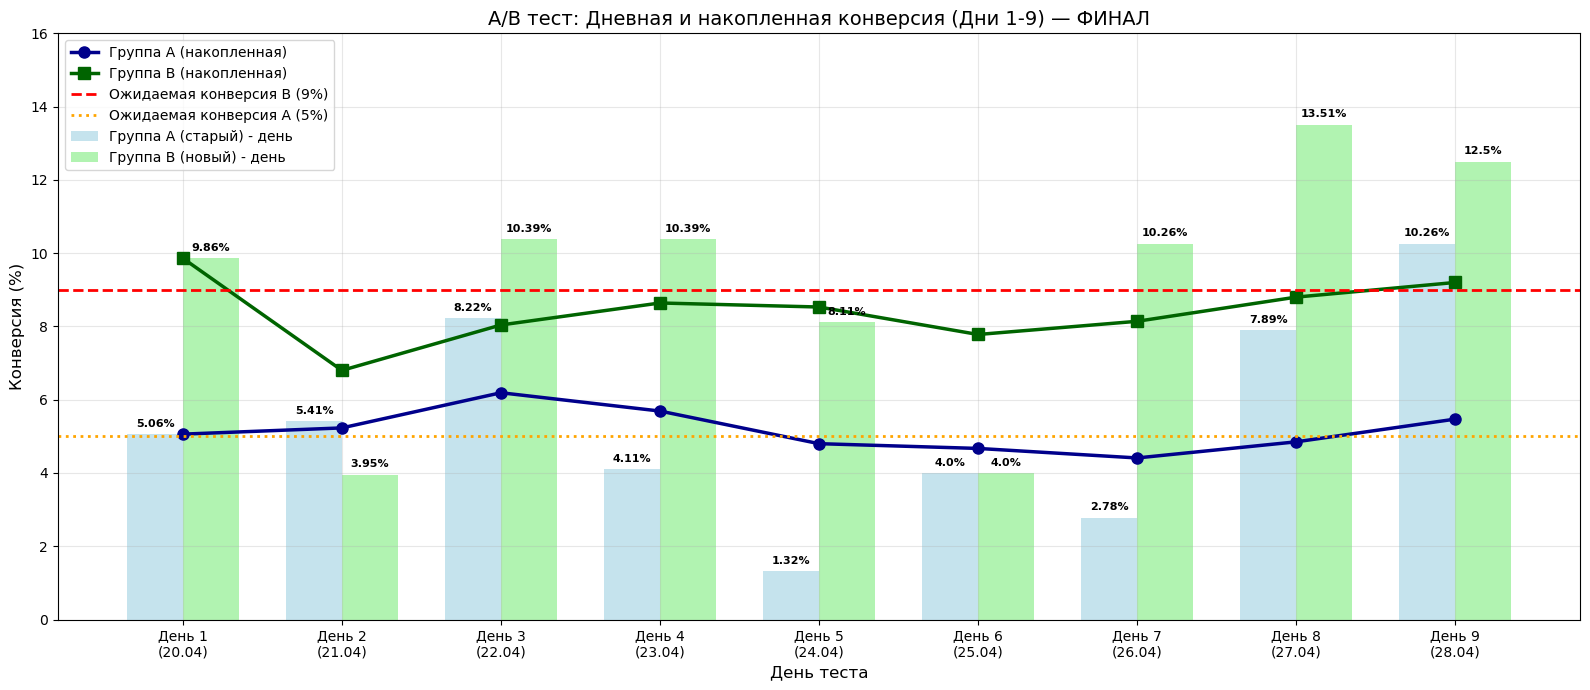


 ФИНАЛЬНАЯ СТАТИСТИКА ПОСЛЕ 9 ДНЕЙ
День   Группа A (день)    Группа B (день)    Группа A (накопл.) Группа B (накопл.)
--------------------------------------------------------------------------------
1        5.06%              9.86%              5.06%              9.86%
2        5.41%              3.95%              5.23%               6.8%
3        8.22%             10.39%              6.19%              8.04%
4        4.11%             10.39%              5.69%              8.64%
5        1.32%              8.11%               4.8%              8.53%
6         4.0%               4.0%              4.67%              7.78%
7        2.78%             10.26%              4.41%              8.14%
8        7.89%             13.51%              4.85%               8.8%
9       10.26%              12.5%              5.47%               9.2%
--------------------------------------------------------------------------------
Сумма      37 пок / 676 чел           62 пок / 674 чел
Конверсия   5.47

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Данные за девять дней
data_all = pd.DataFrame({
    'day': [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9],
    'group': ['A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'B'],
    'conversion': [5.06, 9.86, 5.41, 3.95, 8.22, 10.39, 4.11, 10.39, 1.32, 8.11, 4.00, 4.00, 2.78, 10.26, 7.89, 13.51, 10.26, 12.50]
})

# Подготовка для группового графика
days = [1, 2, 3, 4, 5, 6, 7, 8, 9]
x = np.arange(len(days))
width = 0.35

# Значения конверсии по группам
conv_A = [5.06, 5.41, 8.22, 4.11, 1.32, 4.00, 2.78, 7.89, 10.26]
conv_B = [9.86, 3.95, 10.39, 10.39, 8.11, 4.00, 10.26, 13.51, 12.50]

# Накопленная конверсия
cumulative_A = [5.06, 5.23, 6.19, 5.69, 4.80, 4.67, 4.41, 4.85, 5.47]
cumulative_B = [9.86, 6.80, 8.04, 8.64, 8.53, 7.78, 8.14, 8.80, 9.20]

# Построим график
fig, ax = plt.subplots(figsize=(16, 7))

# Столбцы (дневная конверсия)
bars_A = ax.bar(x - width/2, conv_A, width, label='Группа A (старый) - день', color='lightblue', alpha=0.7)
bars_B = ax.bar(x + width/2, conv_B, width, label='Группа B (новый) - день', color='lightgreen', alpha=0.7)

# Линии накопленной конверсии
ax.plot(x, cumulative_A, 'b-o', linewidth=2.5, markersize=8, label='Группа A (накопленная)', color='darkblue')
ax.plot(x, cumulative_B, 'g-s', linewidth=2.5, markersize=8, label='Группа B (накопленная)', color='darkgreen')

# Линии ожидаемой конверсии
ax.axhline(y=9, color='red', linestyle='--', linewidth=2, label='Ожидаемая конверсия B (9%)')
ax.axhline(y=5, color='orange', linestyle=':', linewidth=2, label='Ожидаемая конверсия A (5%)')

# Настройки
ax.set_xlabel('День теста', fontsize=12)
ax.set_ylabel('Конверсия (%)', fontsize=12)
ax.set_title('A/B тест: Дневная и накопленная конверсия (Дни 1-9) — ФИНАЛ', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['День 1\n(20.04)', 'День 2\n(21.04)', 'День 3\n(22.04)', 
                    'День 4\n(23.04)', 'День 5\n(24.04)', 'День 6\n(25.04)',
                    'День 7\n(26.04)', 'День 8\n(27.04)', 'День 9\n(28.04)'])
ax.set_ylim(0, 16)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Добавим подписи на столбцах
for bars in [bars_A, bars_B]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.2,
                    f'{height}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Вывод финальной статистики
print("\n" + "=" * 80)
print(" ФИНАЛЬНАЯ СТАТИСТИКА ПОСЛЕ 9 ДНЕЙ")
print("=" * 80)
print(f"{'День':<6} {'Группа A (день)':<18} {'Группа B (день)':<18} {'Группа A (накопл.)':<18} {'Группа B (накопл.)':<18}")
print("-" * 80)
for i in range(9):
    print(f"{i+1:<6} {conv_A[i]:>6}% {'':>10} {conv_B[i]:>6}% {'':>10} {cumulative_A[i]:>6}% {'':>10} {cumulative_B[i]:>6}%")
print("-" * 80)
print(f"{'Сумма':<6} {37:>6} пок / 676 чел {'':>5} {62:>6} пок / 674 чел")
print(f"{'Конверсия':<6} {5.47:>6}% {'':>16} {9.20:>6}%")
print("=" * 80)

print(" НАКОПЛЕННАЯ КОНВЕРСИЯ ПО ДНЯМ:")
print("-" * 50)
print(f"После дня 1:  A: 5.06% | B: 9.86% | Разница: +4.80 п.п.")
print(f"После дня 2:  A: 5.23% | B: 6.80% | Разница: +1.57 п.п.")
print(f"После дня 3:  A: 6.19% | B: 8.04% | Разница: +1.85 п.п.")
print(f"После дня 4:  A: 5.69% | B: 8.64% | Разница: +2.95 п.п.")
print(f"После дня 5:  A: 4.80% | B: 8.53% | Разница: +3.73 п.п.")
print(f"После дня 6:  A: 4.67% | B: 7.78% | Разница: +3.11 п.п.")
print(f"После дня 7:  A: 4.41% | B: 8.14% | Разница: +3.73 п.п.")
print(f"После дня 8:  A: 4.85% | B: 8.80% | Разница: +3.95 п.п.")
print(f"После дня 9:  A: 5.47% | B: 9.20% | Разница: +3.73 п.п.")
print("-" * 50)


